In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.base import clone

In [2]:
# load dataset 'dataset_1980_2020.csv'
raw_data = pd.read_csv('dataset_1980_2020.csv')
raw_data.rename(columns={"Count": "Year"}, inplace=True)
print(raw_data.head())

   Year State  0 to 11  12 to 17  Male  Female  Unknown Gender  White  Black  \
0  1980    AL        0        18    13       5               0      7     10   
1  1981    AL        0        21    19       1               0     13      8   
2  1982    AL        1        19    15       4               0      5     14   
3  1983    AL        2        20    21       1               0      7     15   
4  1984    AL        0        21    19       2               0      7     13   

   Amer. Indian/Alaskan Native  ...  Stranger  Unknown  Firearm  Knife  \
0                            1  ...         4        0       15      3   
1                            0  ...         5        0       13      8   
2                            0  ...         6        0        7      5   
3                            0  ...         4        0       13      7   
4                            0  ...         5        2       12      3   

   Blunt object  Personal  Other/unknown Weapon  One offender involved  \


In [3]:
# Load Education data
edu_data = pd.read_csv('education_1980_2019.csv')
print(edu_data.head())
print(edu_data.shape)

   Year State  Less than a high school diploma  High school diploma only  \
0  1980    AL                           5254.0                    2611.0   
1  1980    AL                          11666.0                    7011.0   
2  1980    AL                           9678.0                    5578.0   
3  1980    AL                         141531.0                  132921.0   
4  1980    AL                          11841.0                    7947.0   

   Percent of adults with less than a high school diploma  \
0                                               59.5        
1                                               53.9        
2                                               54.0        
3                                               35.3        
4                                               50.1        

   Percent of adults with a high school diploma only  
0                                               29.6  
1                                               32.4  
2          

Using `.mean()` to aggregate different counties/district of a state into one single average for each state in a year. `mean()` is used because this  data does not have population weights, and we want to a general average of each states education

In [4]:
edu_grouped = edu_data.groupby(['Year', 'State'], as_index=False)[
    ['Percent of adults with less than a high school diploma',
     'Percent of adults with a high school diploma only']
].mean()

print(edu_grouped.head())

   Year State  Percent of adults with less than a high school diploma  \
0  1980    AK                                          28.200000        
1  1980    AL                                          50.620588        
2  1980    AR                                          50.073684        
3  1980    AZ                                          34.780000        
4  1980    CA                                          27.350847        

   Percent of adults with a high school diploma only  
0                                          35.660000  
1                                          30.066176  
2                                          32.198684  
3                                          33.806667  
4                                          33.994915  


In [5]:
merged_data = pd.merge(raw_data, edu_grouped, on=['Year', 'State'], how='left')
merged_data.dropna(inplace=True)
print(merged_data.head())


    Year State  0 to 11  12 to 17  Male  Female  Unknown Gender  White  Black  \
0   1980    AL        0        18    13       5               0      7     10   
10  1990    AL        0        34    32       2               0     10     24   
19  2000    AL        0         6     6       0               0      0      6   
30  1980    AK        0         2     2       0               0      0      0   
40  1990    AK        0         3     3       0               0      3      0   

    Amer. Indian/Alaskan Native  ...  Firearm  Knife  Blunt object  Personal  \
0                             1  ...       15      3             0         0   
10                            0  ...       27      3             2         0   
19                            0  ...        3      1             0         0   
30                            2  ...        1      0             0         1   
40                            0  ...        3      0             0         0   

    Other/unknown Weapon  One of

### Predictive Modeling but with education included

In [6]:
# give states a numerical value
encoder = LabelEncoder()
merged_data["State"] = encoder.fit_transform(merged_data["State"])

# all the feature groups
gender_targets = ["Male", "Female"]
race_targets = ["White", "Black", "Amer. Indian/Alaskan Native", "Asian/Nat. Hawaiian/Pac Isl"]
relation_targets = ["Family", "Acquaintance", "Stranger"]
weapon_targets = ["Firearm", "Knife", "Blunt object", "Personal"]
offenders_targets = ["One offender involved", "Two or more offenders involved"]
education_targets = [
    "Percent of adults with less than a high school diploma",
    "Percent of adults with a high school diploma only"
]

all_targets = [gender_targets, race_targets, relation_targets, weapon_targets, offenders_targets, education_targets]
all_target_names = ["Gender", "Race", "Relation", "Weapon", "Offenders", "Education"]

# feature = everything except Year and target variables
all_target_columns = sum(all_targets, [])  # flatten target lists
X = merged_data.drop(columns=all_target_columns + ["Year"])  # drop targets and 'Year' column
features = X.columns  # Define features

y_all = [merged_data[targets] for targets in all_targets]  # target variables

MODEL: Linear Regression

-------------------- Category: Gender --------------------
Targets: ['Male', 'Female']
------------------------------------------------------------


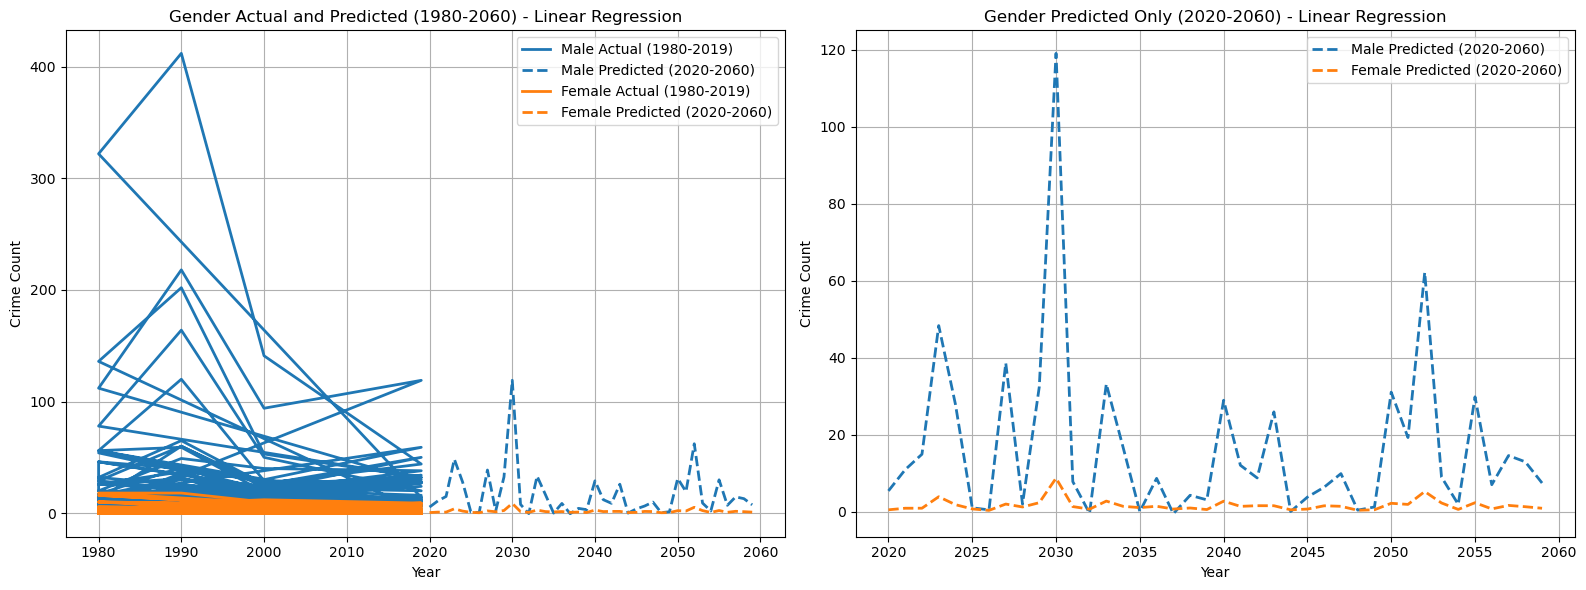


-------------------- Category: Race --------------------
Targets: ['White', 'Black', 'Amer. Indian/Alaskan Native', 'Asian/Nat. Hawaiian/Pac Isl']
------------------------------------------------------------


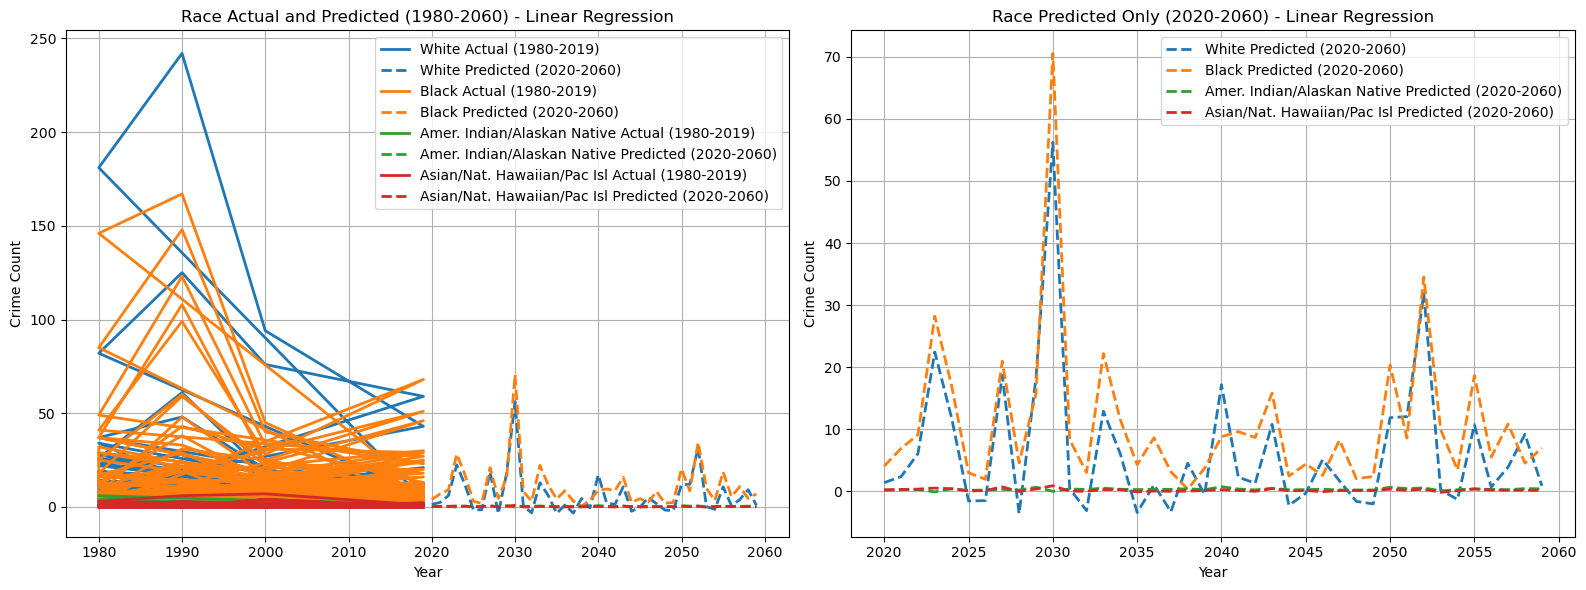


-------------------- Category: Relation --------------------
Targets: ['Family', 'Acquaintance', 'Stranger']
------------------------------------------------------------


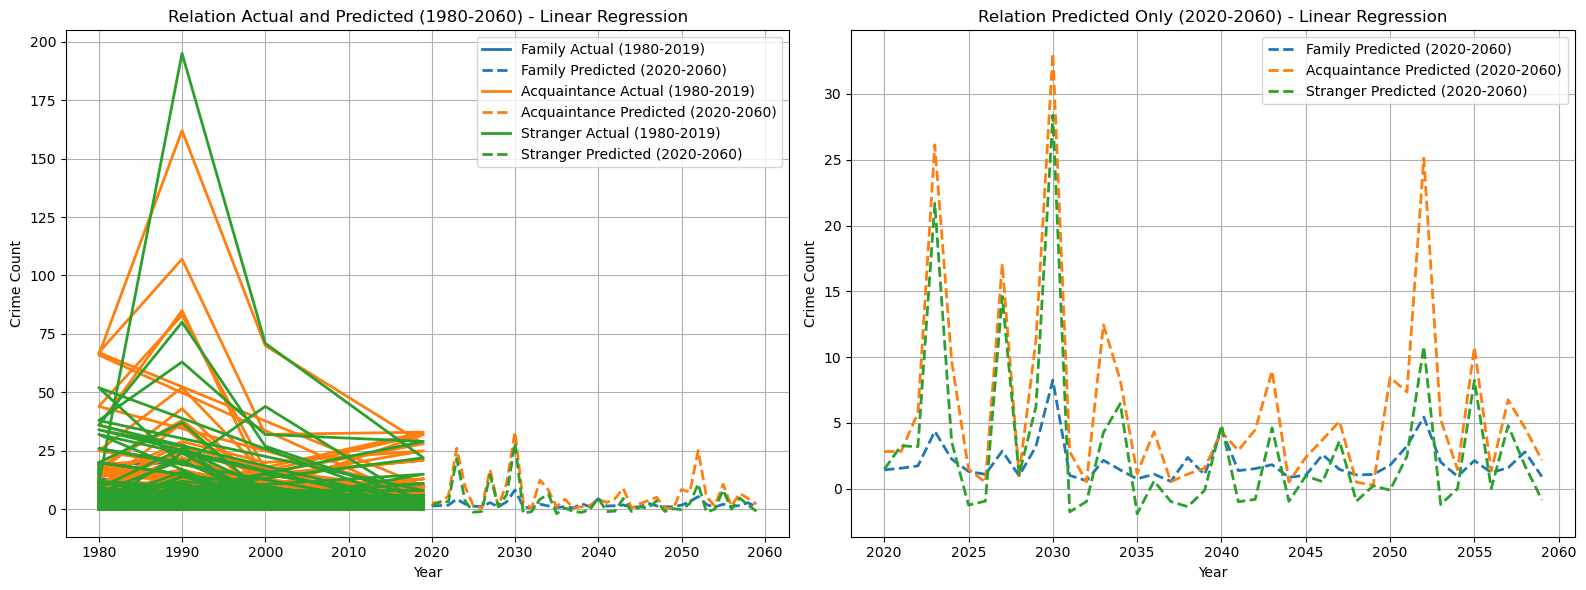


-------------------- Category: Weapon --------------------
Targets: ['Firearm', 'Knife', 'Blunt object', 'Personal']
------------------------------------------------------------


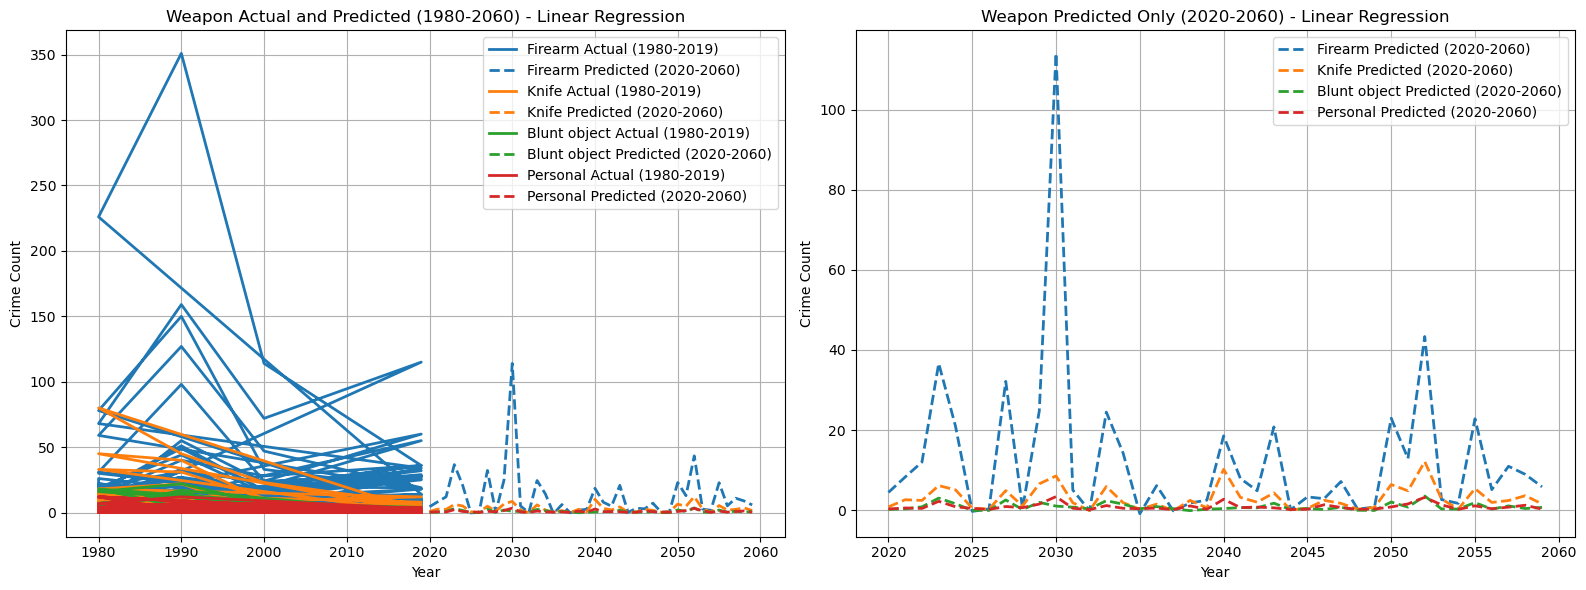


-------------------- Category: Offenders --------------------
Targets: ['One offender involved', 'Two or more offenders involved']
------------------------------------------------------------


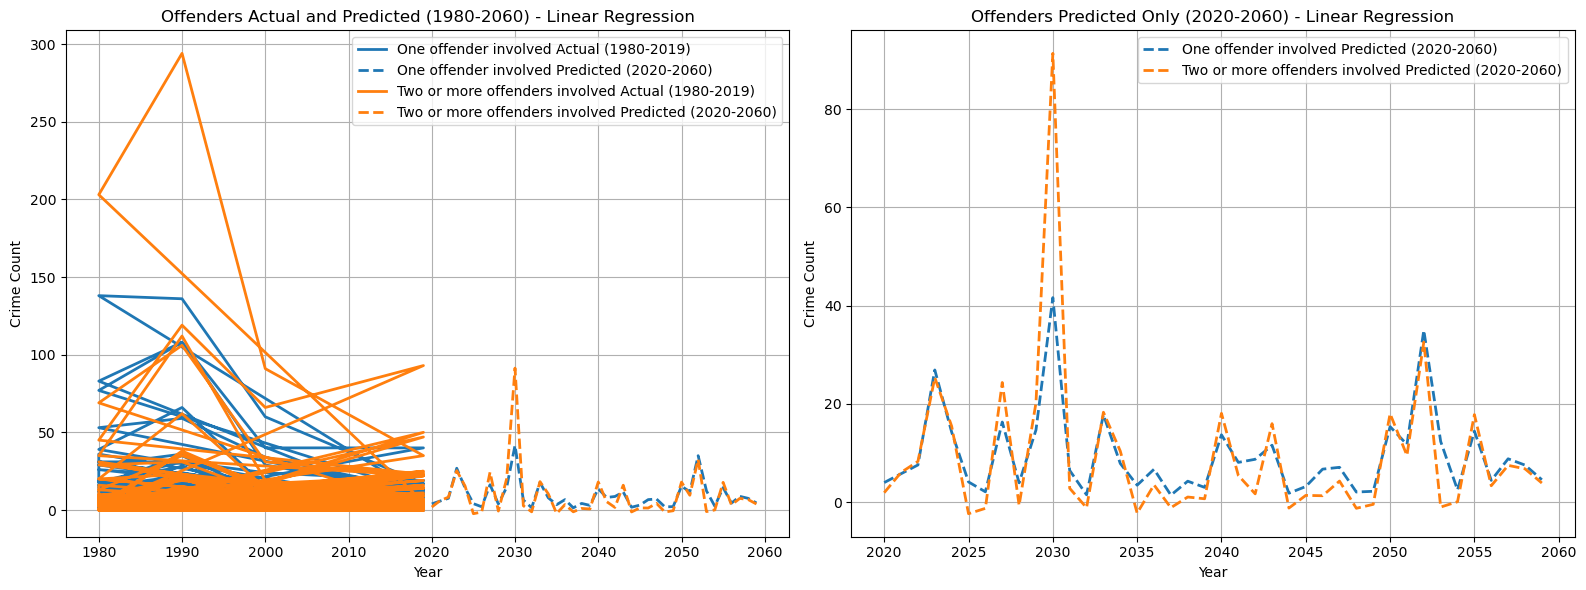


-------------------- Category: Education --------------------
Targets: ['Percent of adults with less than a high school diploma', 'Percent of adults with a high school diploma only']
------------------------------------------------------------


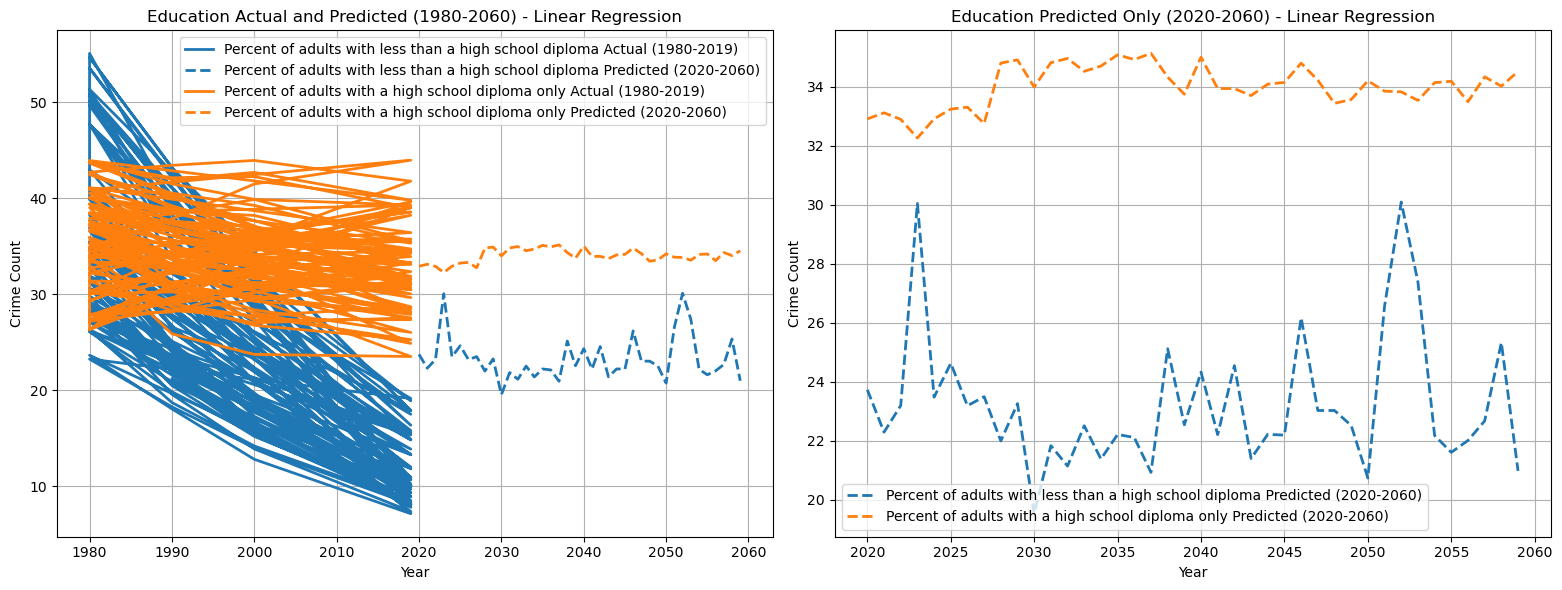

                                               Target   Category  \
0                                                Male     Gender   
1                                              Female     Gender   
2                                               White       Race   
3                                               Black       Race   
4                         Amer. Indian/Alaskan Native       Race   
5                         Asian/Nat. Hawaiian/Pac Isl       Race   
6                                              Family   Relation   
7                                        Acquaintance   Relation   
8                                            Stranger   Relation   
9                                             Firearm     Weapon   
10                                              Knife     Weapon   
11                                       Blunt object     Weapon   
12                                           Personal     Weapon   
13                              One offender inv

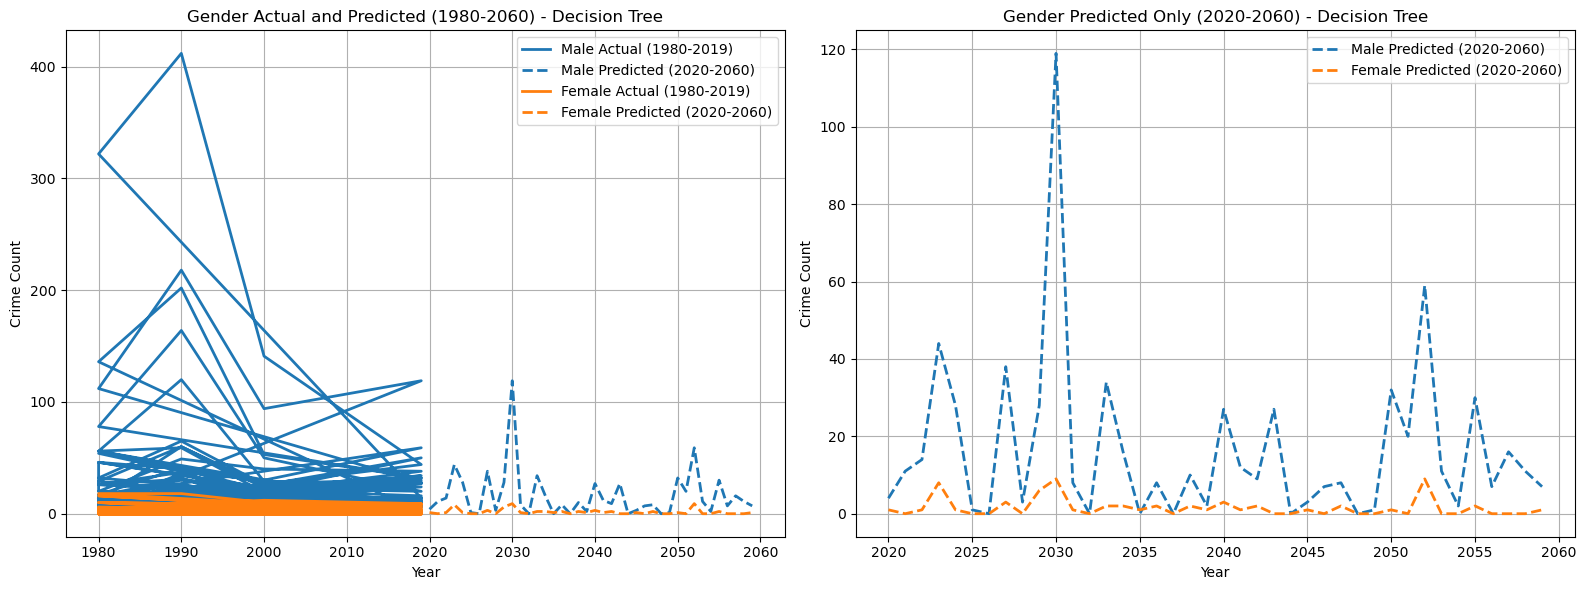


-------------------- Category: Race --------------------
Targets: ['White', 'Black', 'Amer. Indian/Alaskan Native', 'Asian/Nat. Hawaiian/Pac Isl']
------------------------------------------------------------


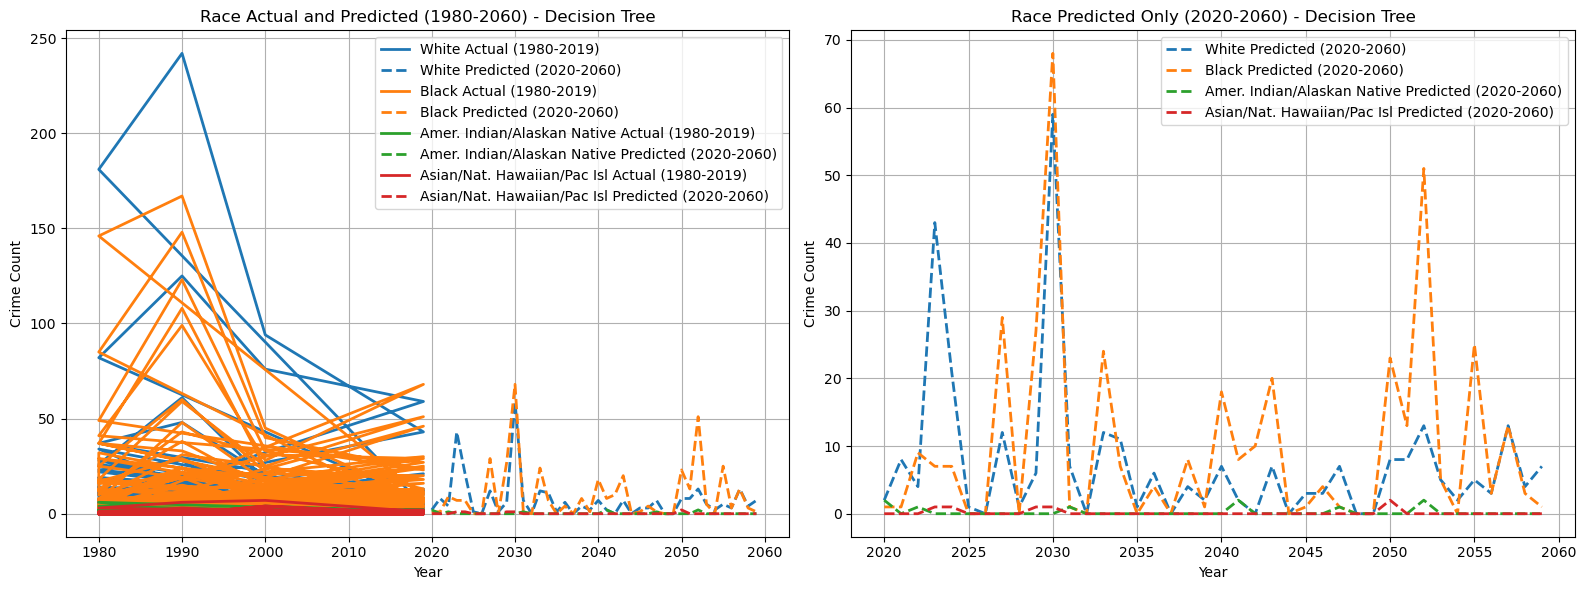


-------------------- Category: Relation --------------------
Targets: ['Family', 'Acquaintance', 'Stranger']
------------------------------------------------------------


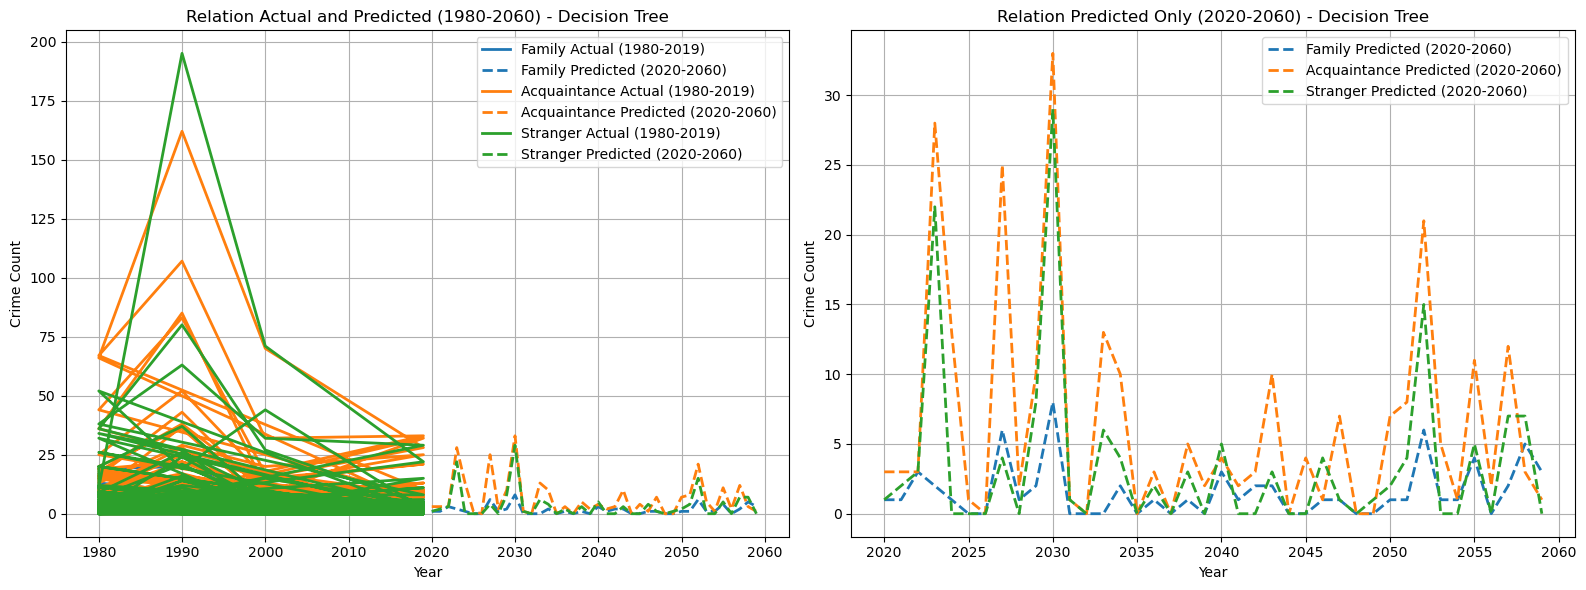


-------------------- Category: Weapon --------------------
Targets: ['Firearm', 'Knife', 'Blunt object', 'Personal']
------------------------------------------------------------


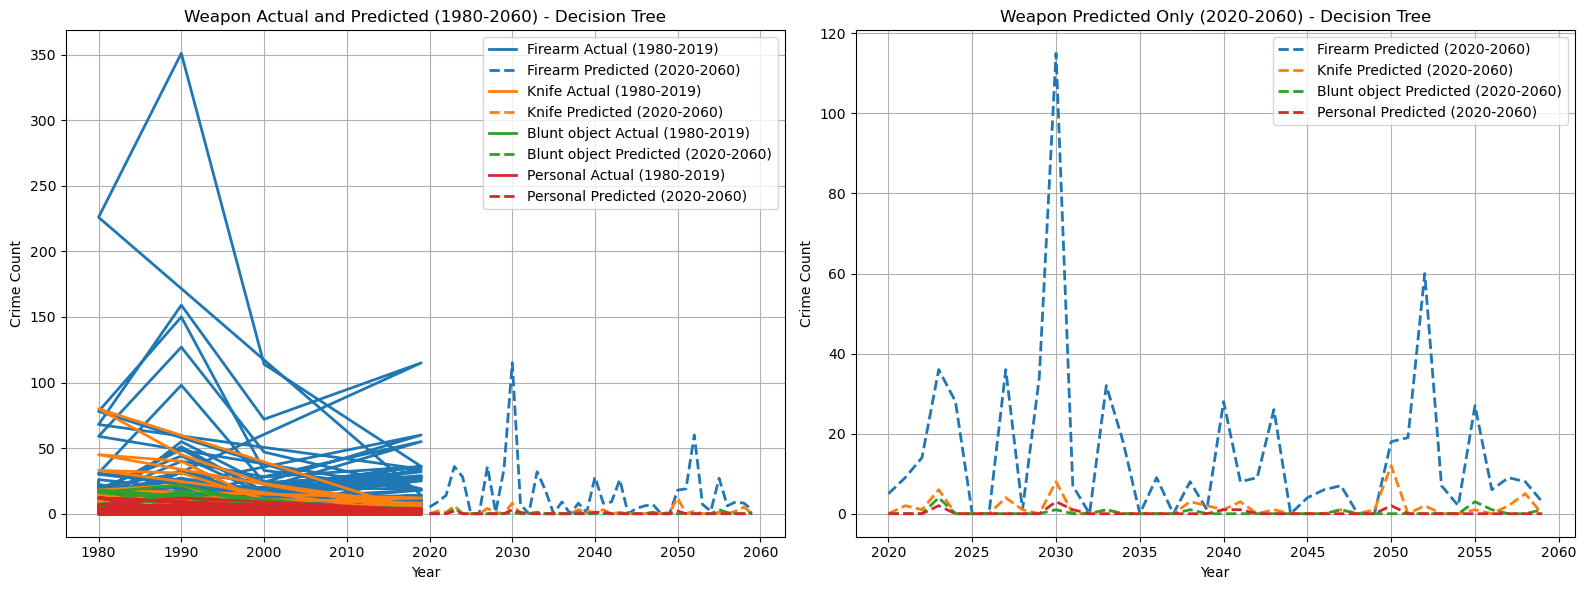


-------------------- Category: Offenders --------------------
Targets: ['One offender involved', 'Two or more offenders involved']
------------------------------------------------------------


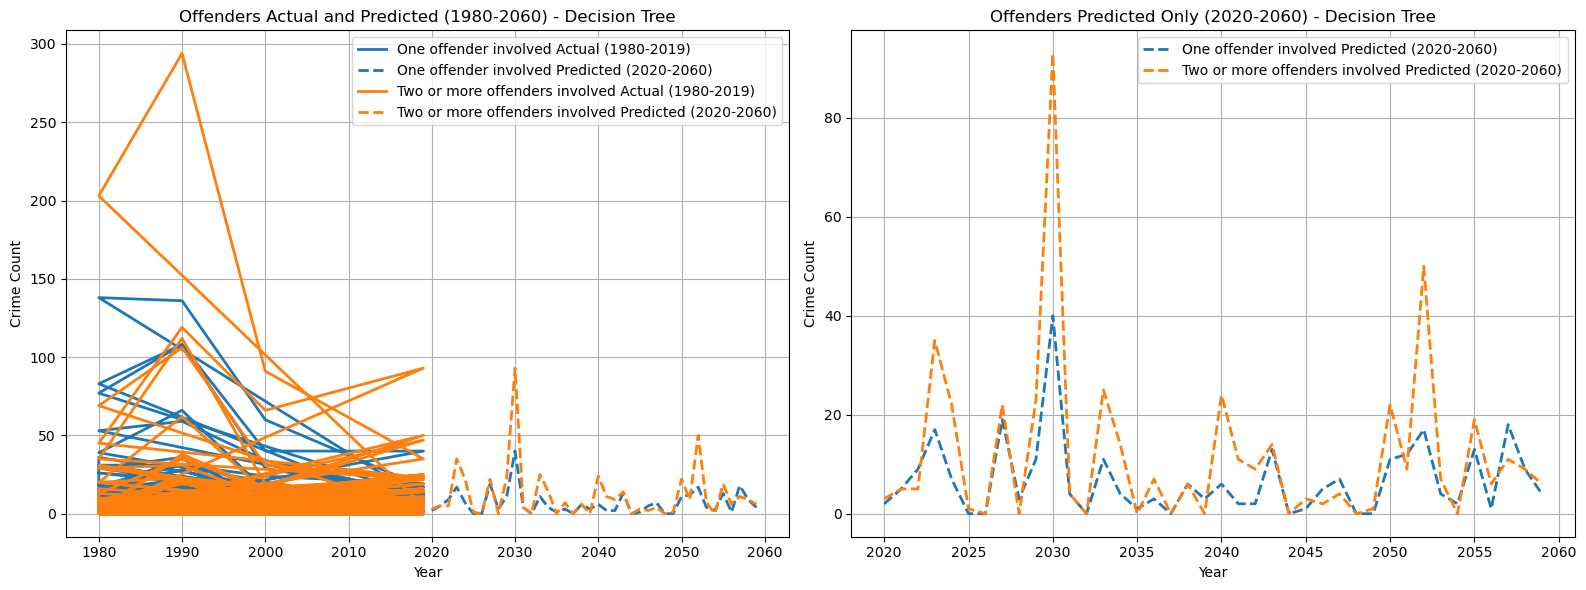


-------------------- Category: Education --------------------
Targets: ['Percent of adults with less than a high school diploma', 'Percent of adults with a high school diploma only']
------------------------------------------------------------


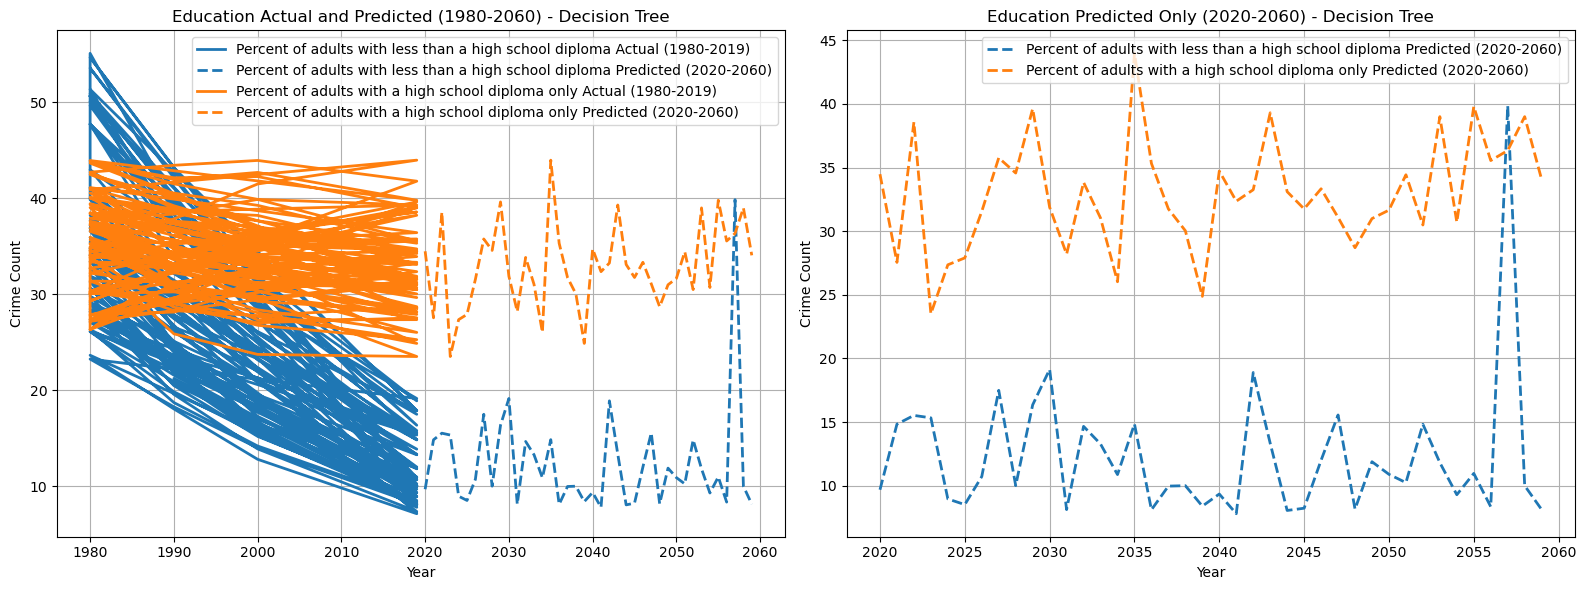

                                               Target   Category  \
0                                                Male     Gender   
1                                              Female     Gender   
2                                               White       Race   
3                                               Black       Race   
4                         Amer. Indian/Alaskan Native       Race   
5                         Asian/Nat. Hawaiian/Pac Isl       Race   
6                                              Family   Relation   
7                                        Acquaintance   Relation   
8                                            Stranger   Relation   
9                                             Firearm     Weapon   
10                                              Knife     Weapon   
11                                       Blunt object     Weapon   
12                                           Personal     Weapon   
13                              One offender inv

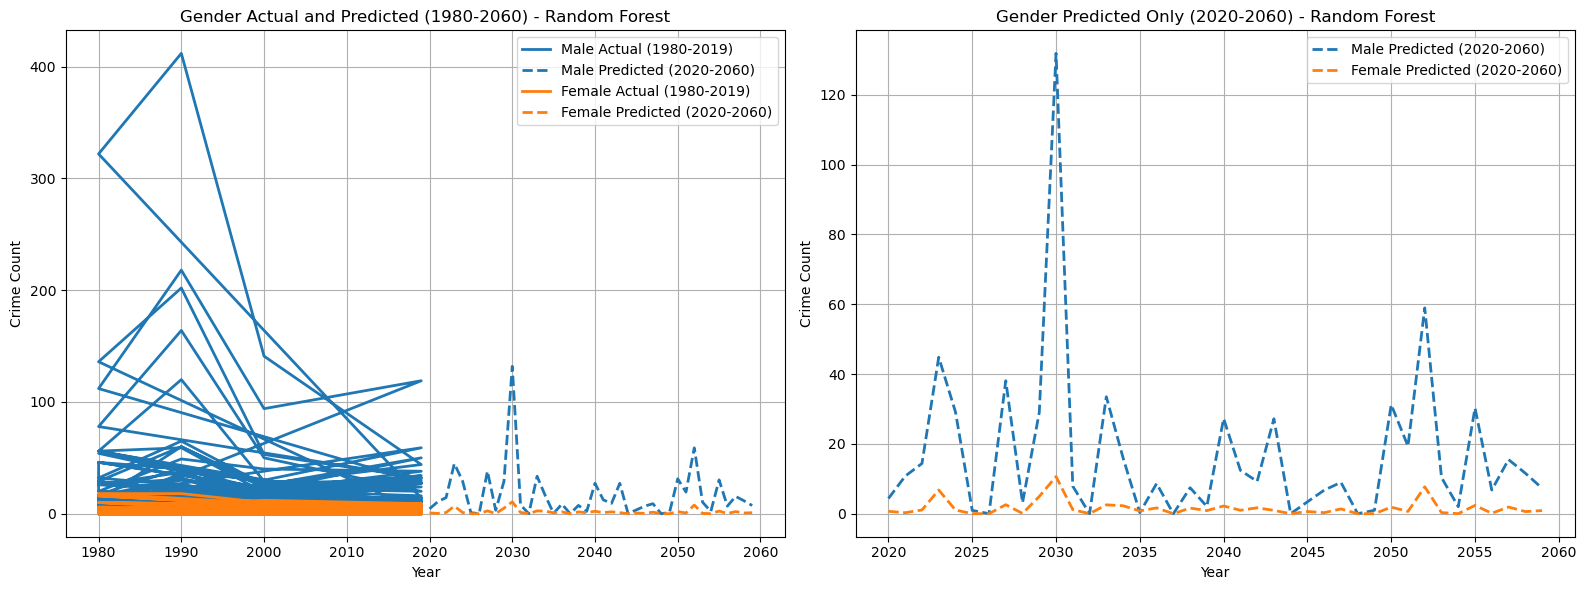


-------------------- Category: Race --------------------
Targets: ['White', 'Black', 'Amer. Indian/Alaskan Native', 'Asian/Nat. Hawaiian/Pac Isl']
------------------------------------------------------------


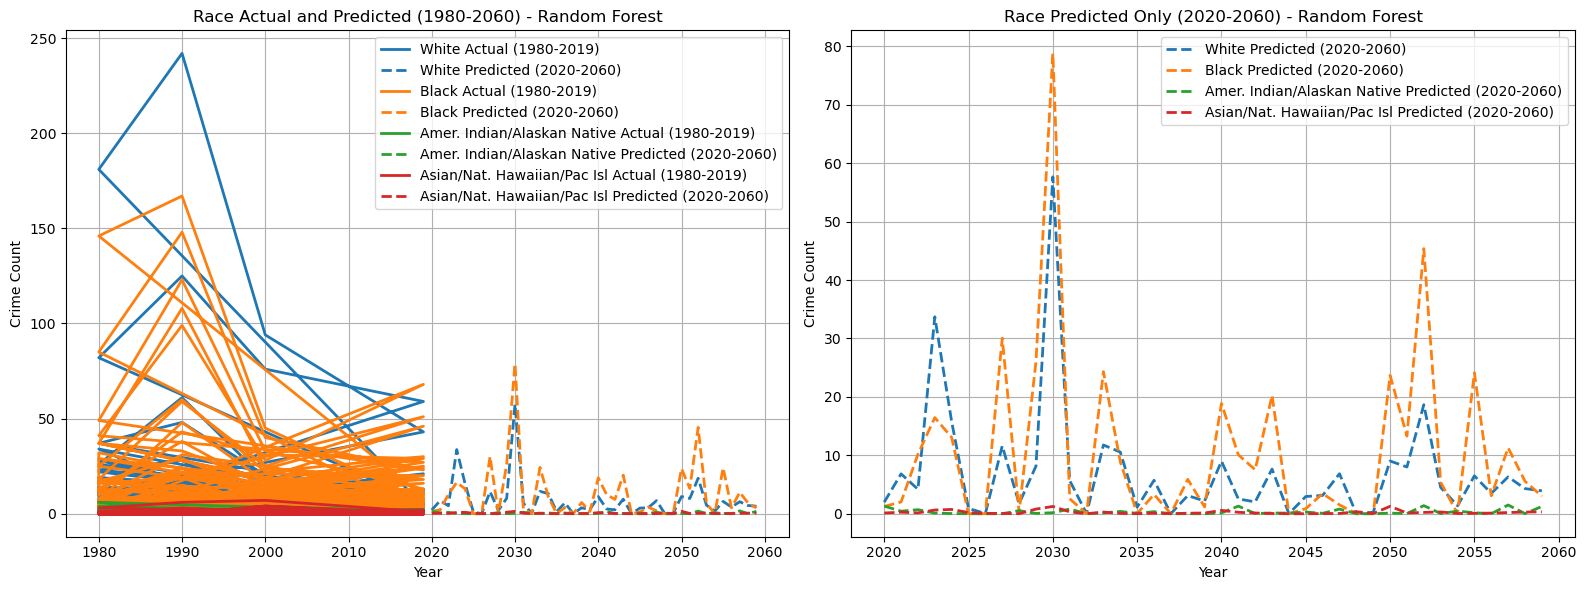


-------------------- Category: Relation --------------------
Targets: ['Family', 'Acquaintance', 'Stranger']
------------------------------------------------------------


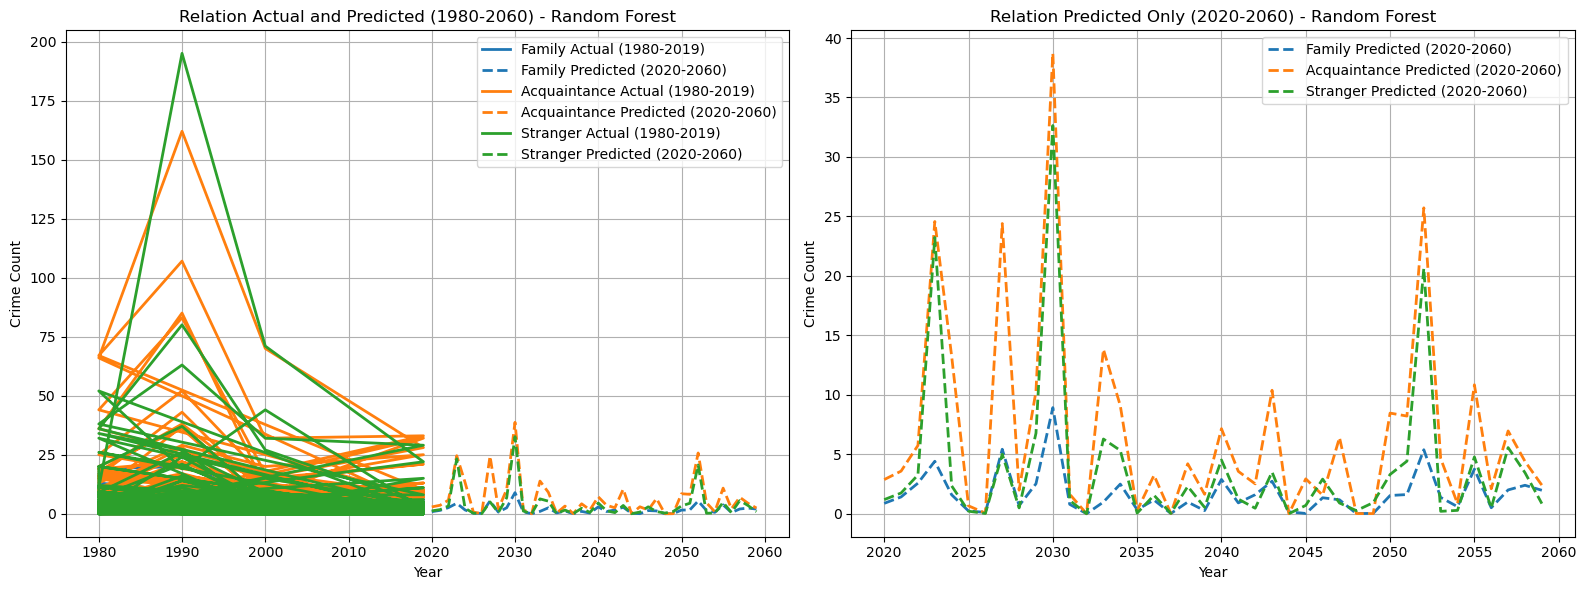


-------------------- Category: Weapon --------------------
Targets: ['Firearm', 'Knife', 'Blunt object', 'Personal']
------------------------------------------------------------


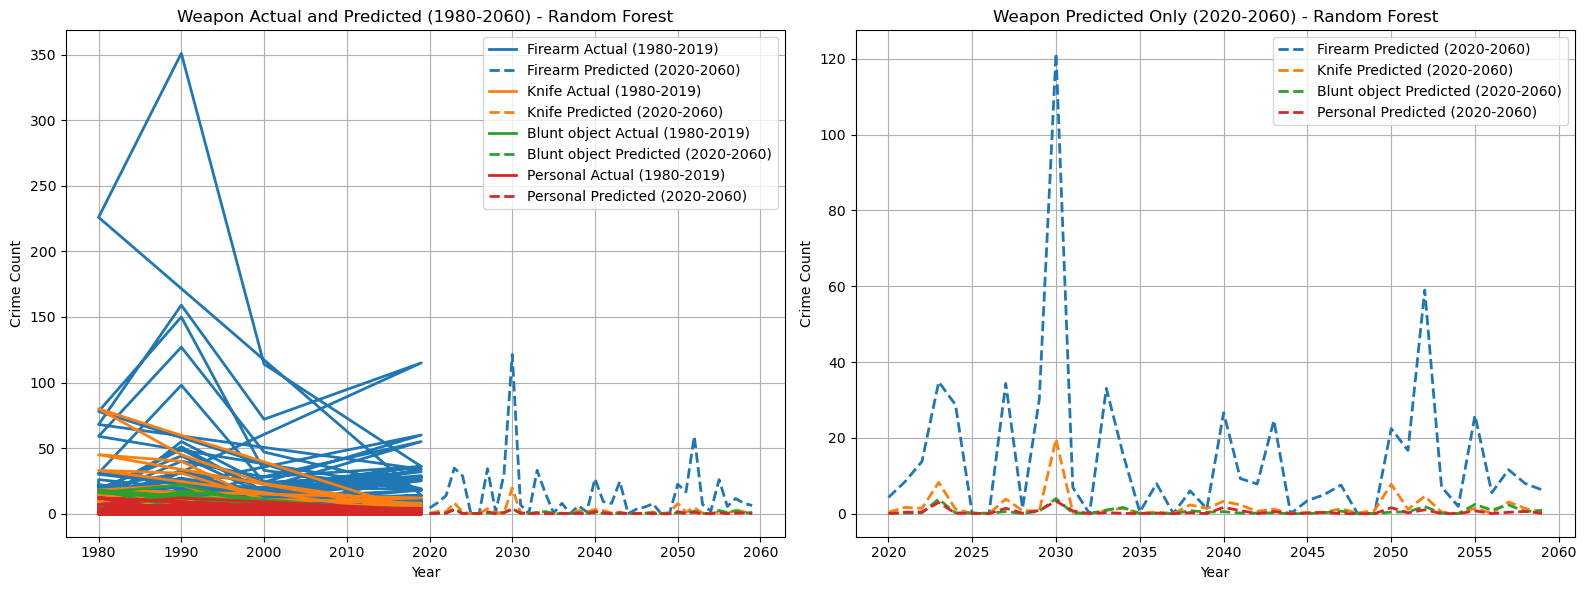


-------------------- Category: Offenders --------------------
Targets: ['One offender involved', 'Two or more offenders involved']
------------------------------------------------------------


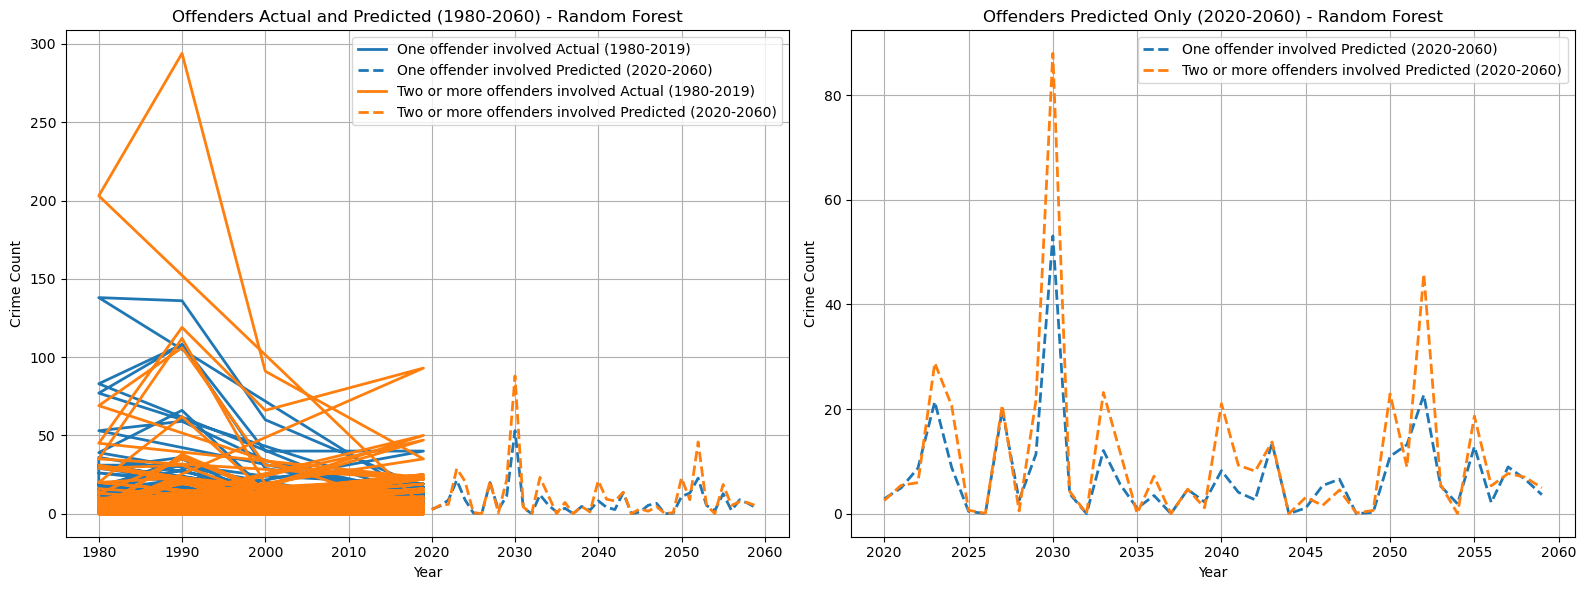


-------------------- Category: Education --------------------
Targets: ['Percent of adults with less than a high school diploma', 'Percent of adults with a high school diploma only']
------------------------------------------------------------


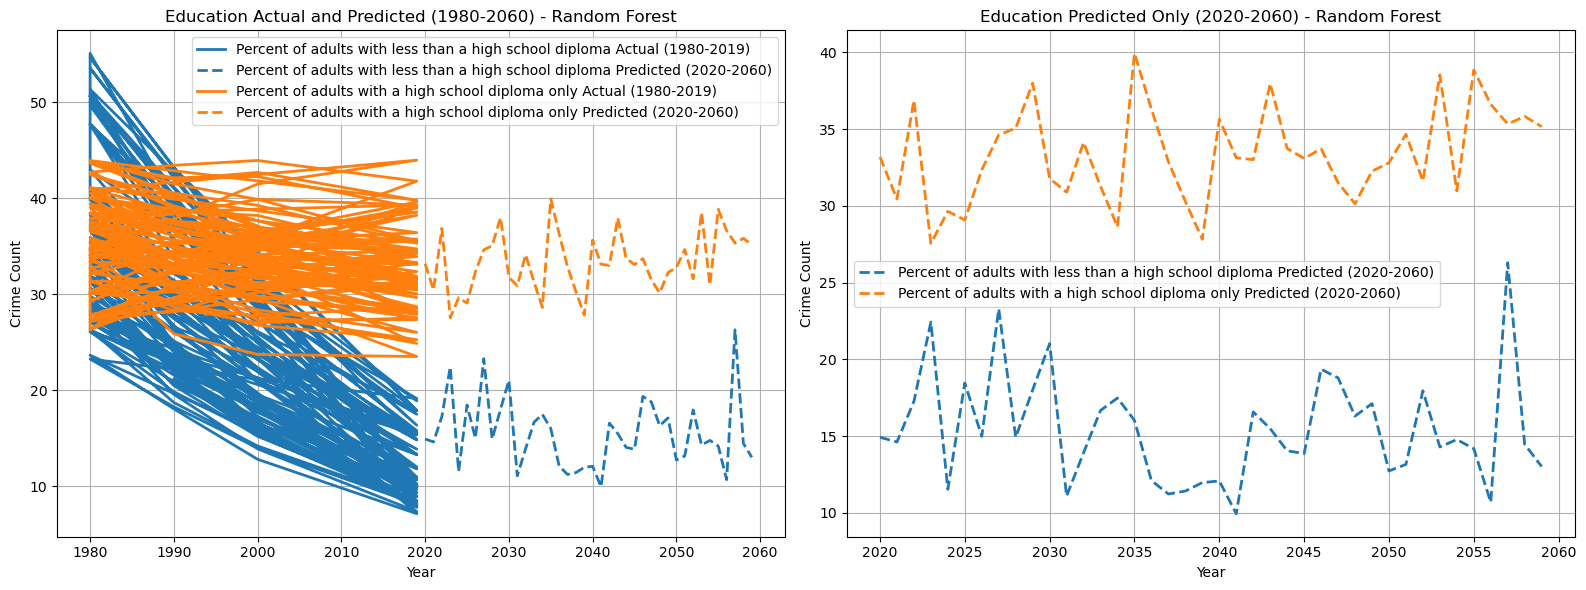

                                               Target   Category  \
0                                                Male     Gender   
1                                              Female     Gender   
2                                               White       Race   
3                                               Black       Race   
4                         Amer. Indian/Alaskan Native       Race   
5                         Asian/Nat. Hawaiian/Pac Isl       Race   
6                                              Family   Relation   
7                                        Acquaintance   Relation   
8                                            Stranger   Relation   
9                                             Firearm     Weapon   
10                                              Knife     Weapon   
11                                       Blunt object     Weapon   
12                                           Personal     Weapon   
13                              One offender inv

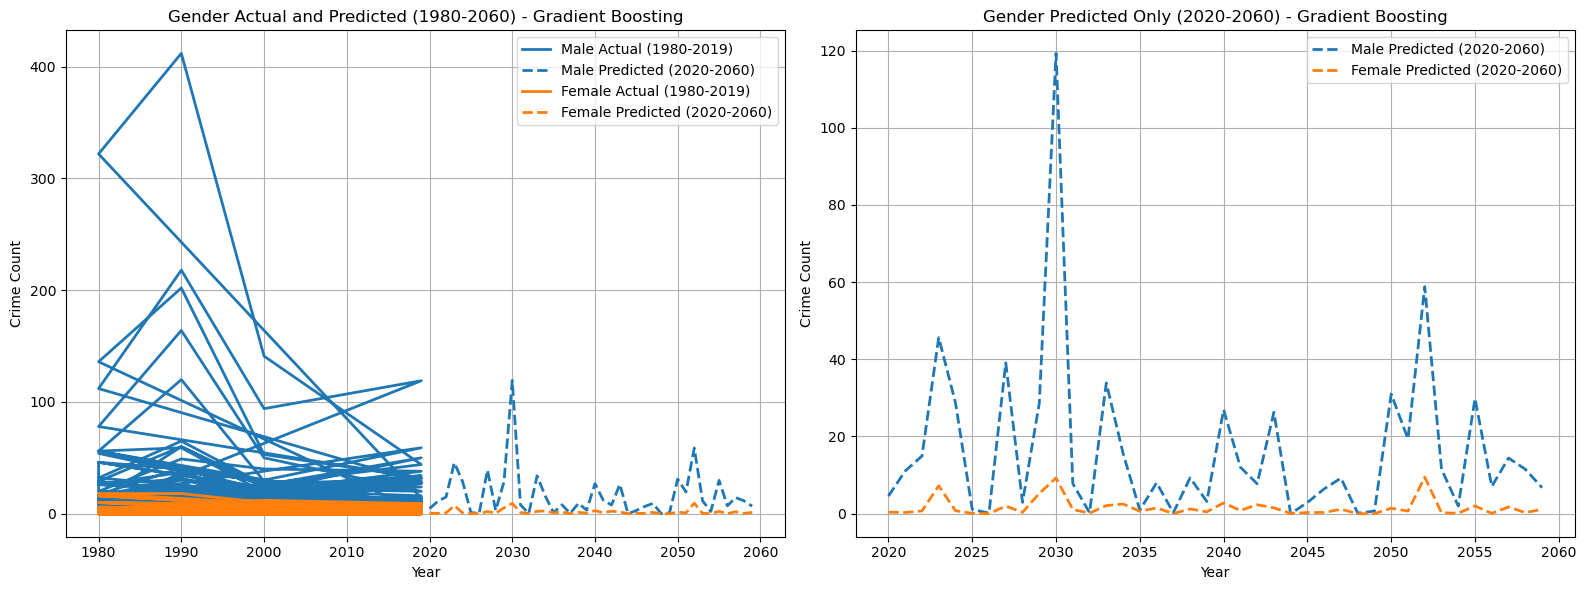


-------------------- Category: Race --------------------
Targets: ['White', 'Black', 'Amer. Indian/Alaskan Native', 'Asian/Nat. Hawaiian/Pac Isl']
------------------------------------------------------------


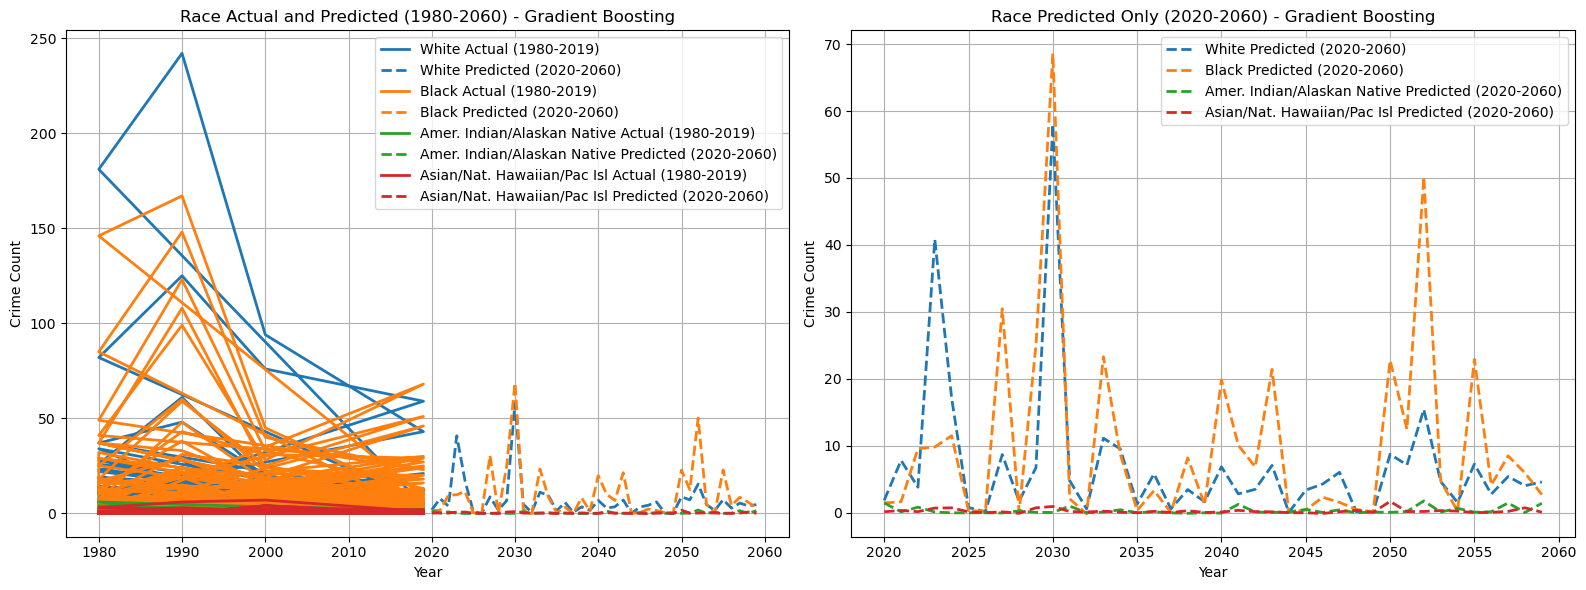


-------------------- Category: Relation --------------------
Targets: ['Family', 'Acquaintance', 'Stranger']
------------------------------------------------------------


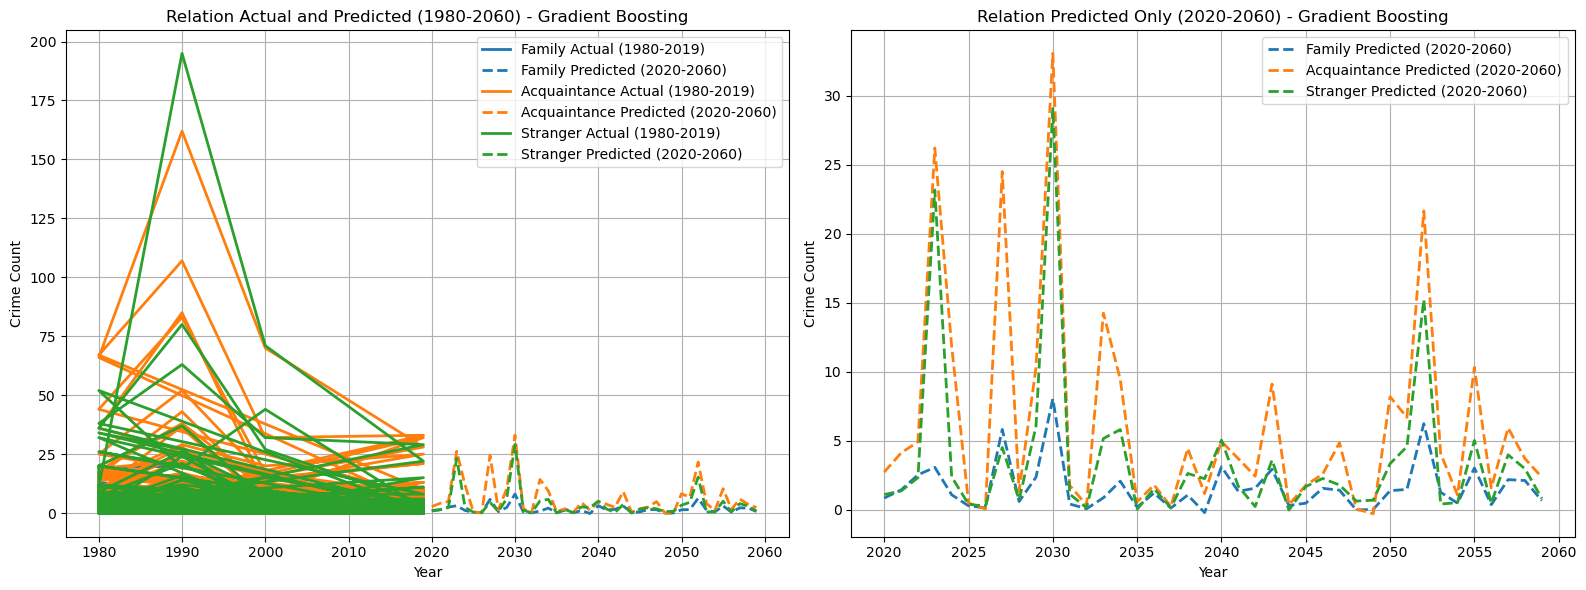


-------------------- Category: Weapon --------------------
Targets: ['Firearm', 'Knife', 'Blunt object', 'Personal']
------------------------------------------------------------


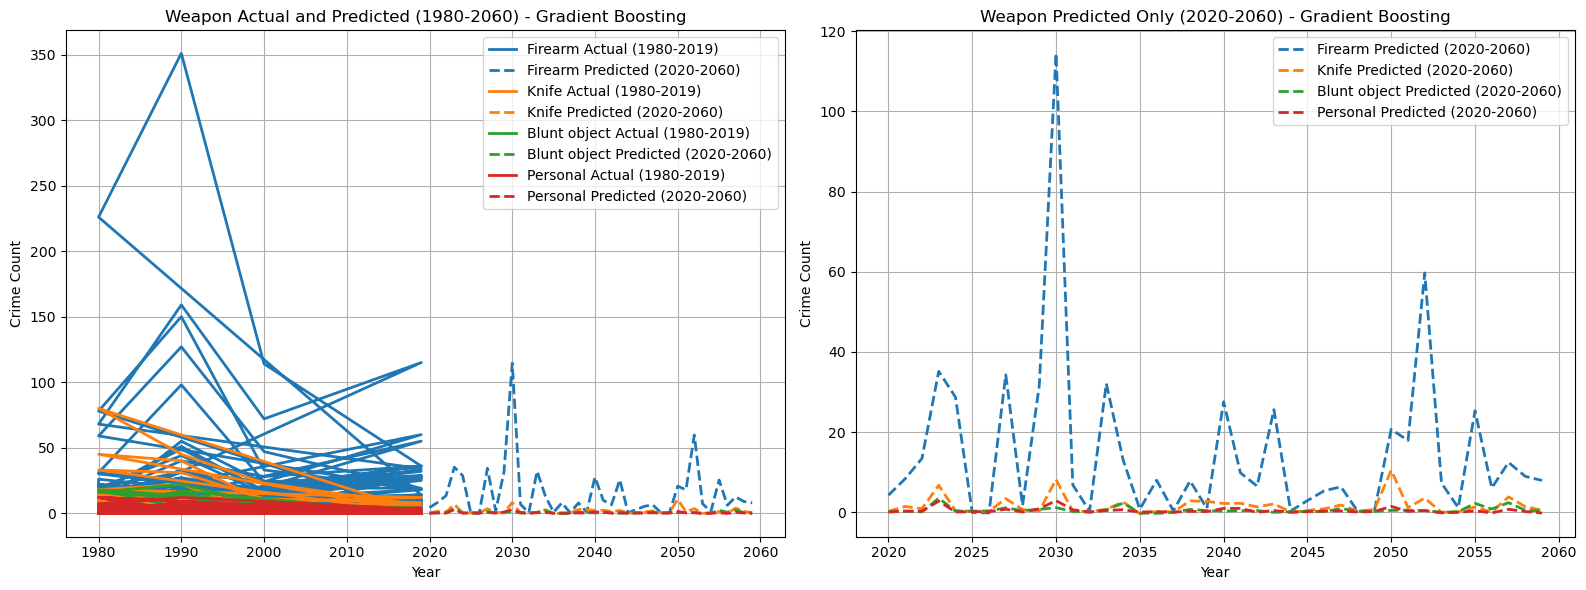


-------------------- Category: Offenders --------------------
Targets: ['One offender involved', 'Two or more offenders involved']
------------------------------------------------------------


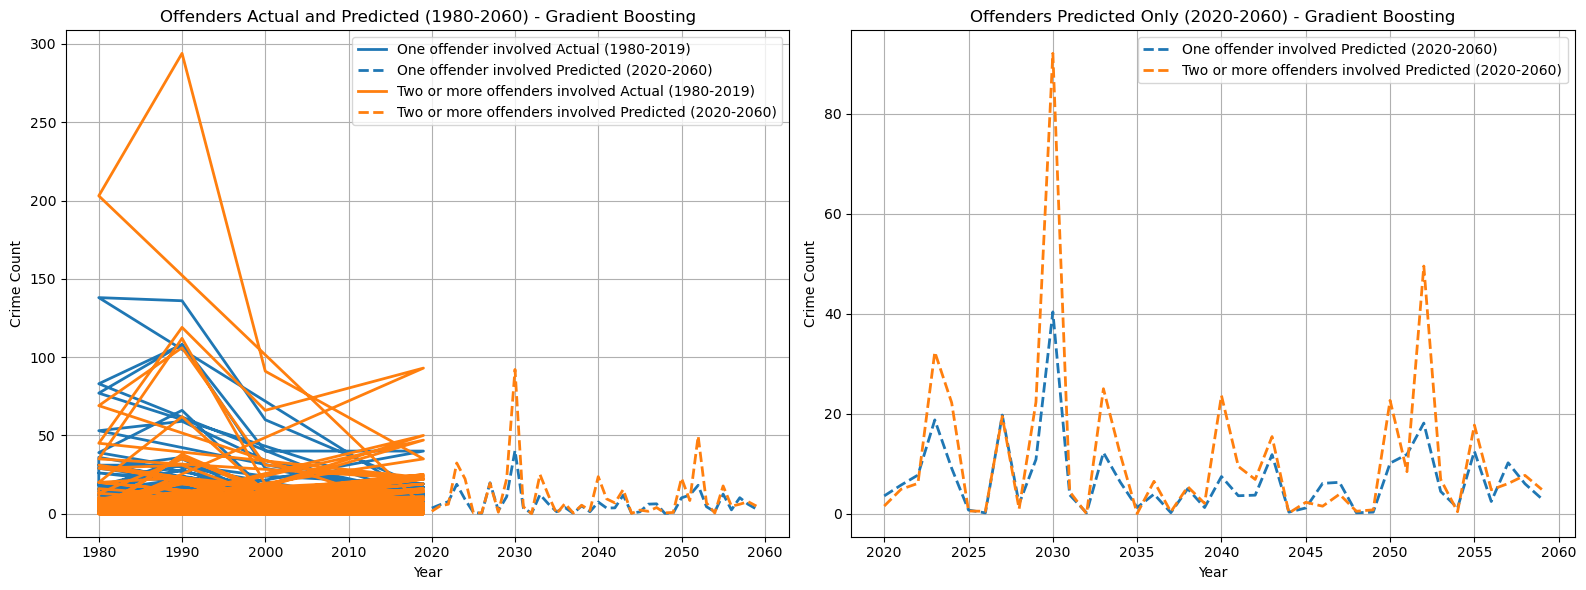


-------------------- Category: Education --------------------
Targets: ['Percent of adults with less than a high school diploma', 'Percent of adults with a high school diploma only']
------------------------------------------------------------


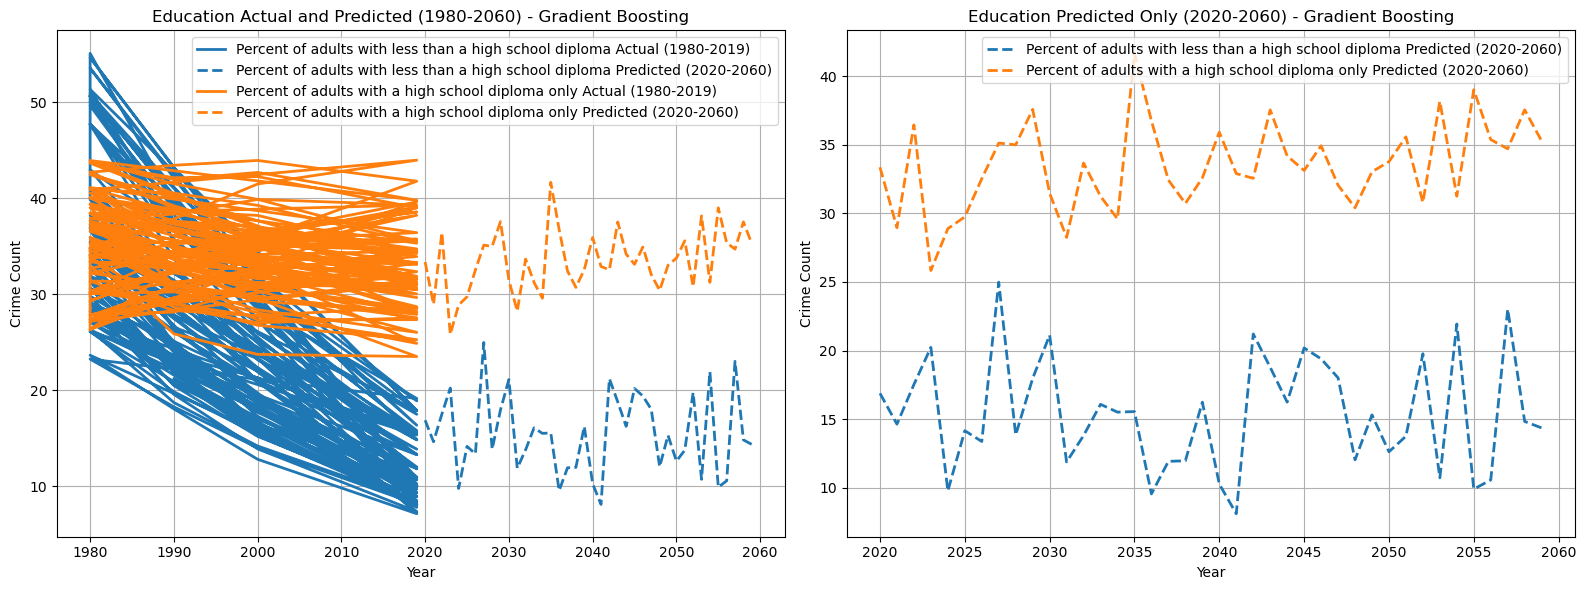

                                               Target   Category  \
0                                                Male     Gender   
1                                              Female     Gender   
2                                               White       Race   
3                                               Black       Race   
4                         Amer. Indian/Alaskan Native       Race   
5                         Asian/Nat. Hawaiian/Pac Isl       Race   
6                                              Family   Relation   
7                                        Acquaintance   Relation   
8                                            Stranger   Relation   
9                                             Firearm     Weapon   
10                                              Knife     Weapon   
11                                       Blunt object     Weapon   
12                                           Personal     Weapon   
13                              One offender inv

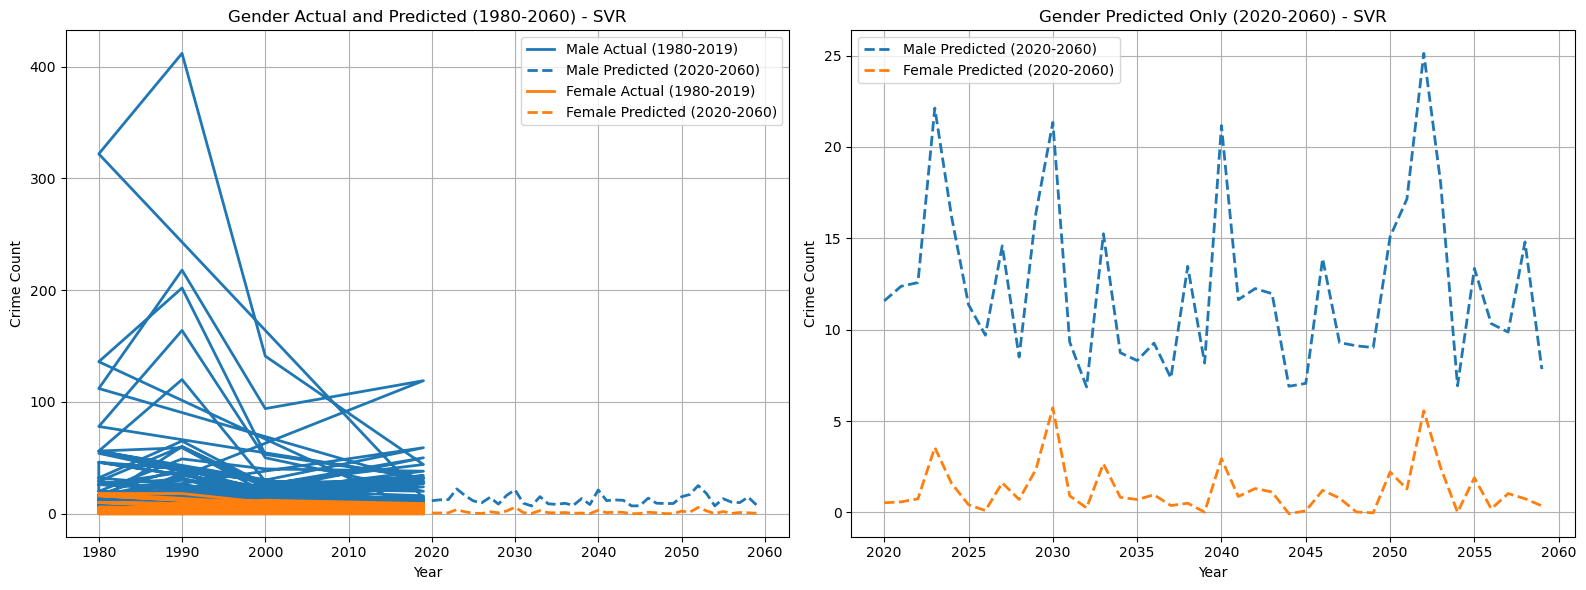


-------------------- Category: Race --------------------
Targets: ['White', 'Black', 'Amer. Indian/Alaskan Native', 'Asian/Nat. Hawaiian/Pac Isl']
------------------------------------------------------------


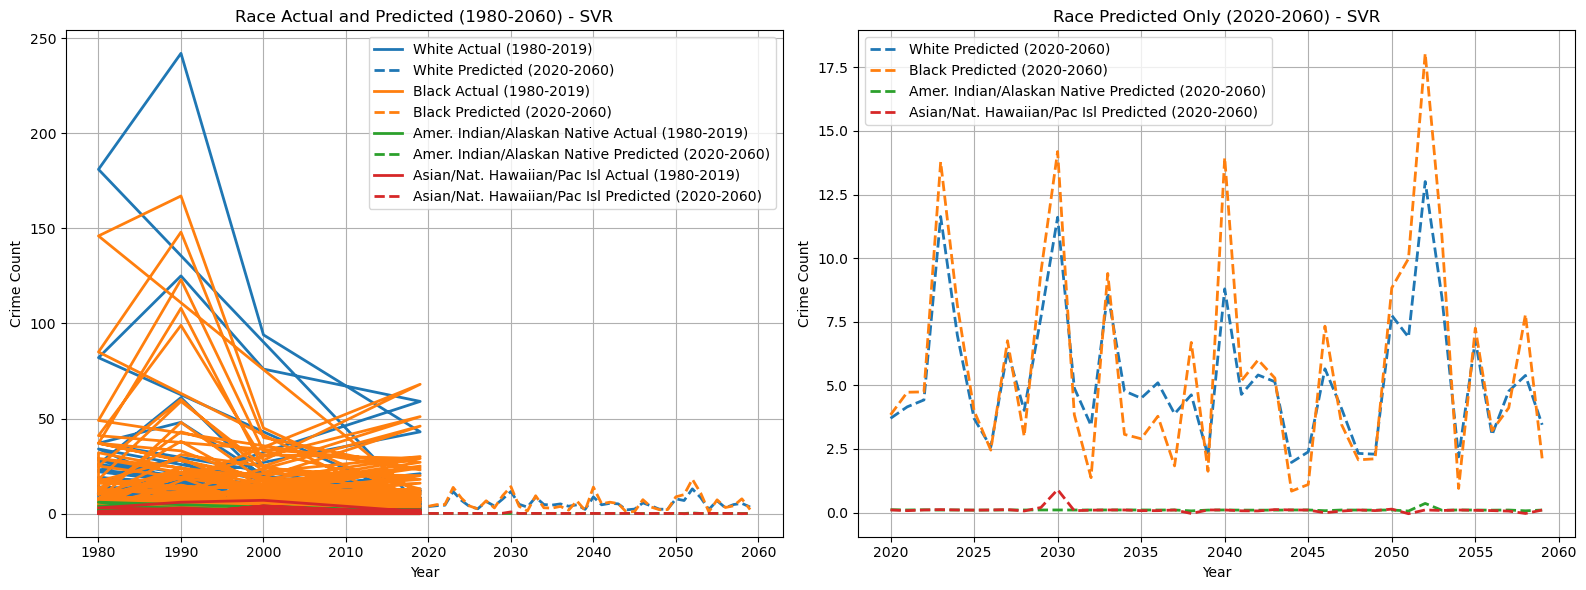


-------------------- Category: Relation --------------------
Targets: ['Family', 'Acquaintance', 'Stranger']
------------------------------------------------------------


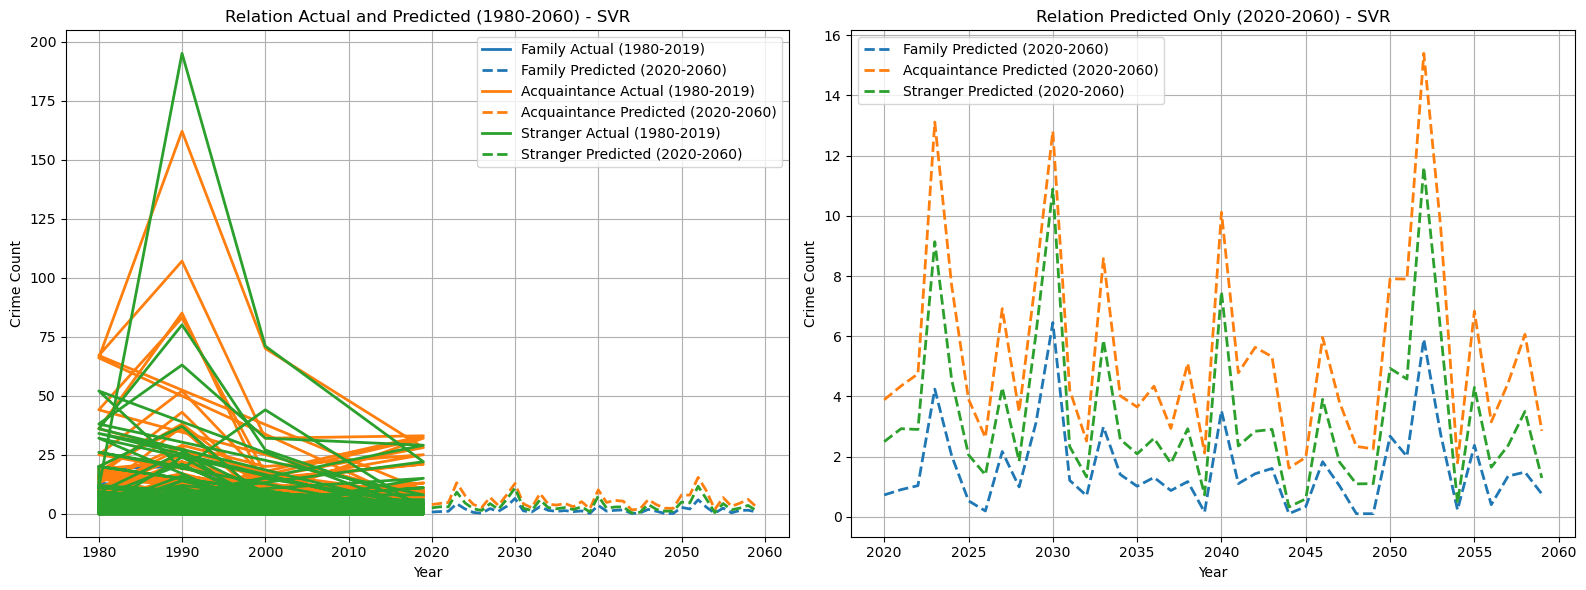


-------------------- Category: Weapon --------------------
Targets: ['Firearm', 'Knife', 'Blunt object', 'Personal']
------------------------------------------------------------


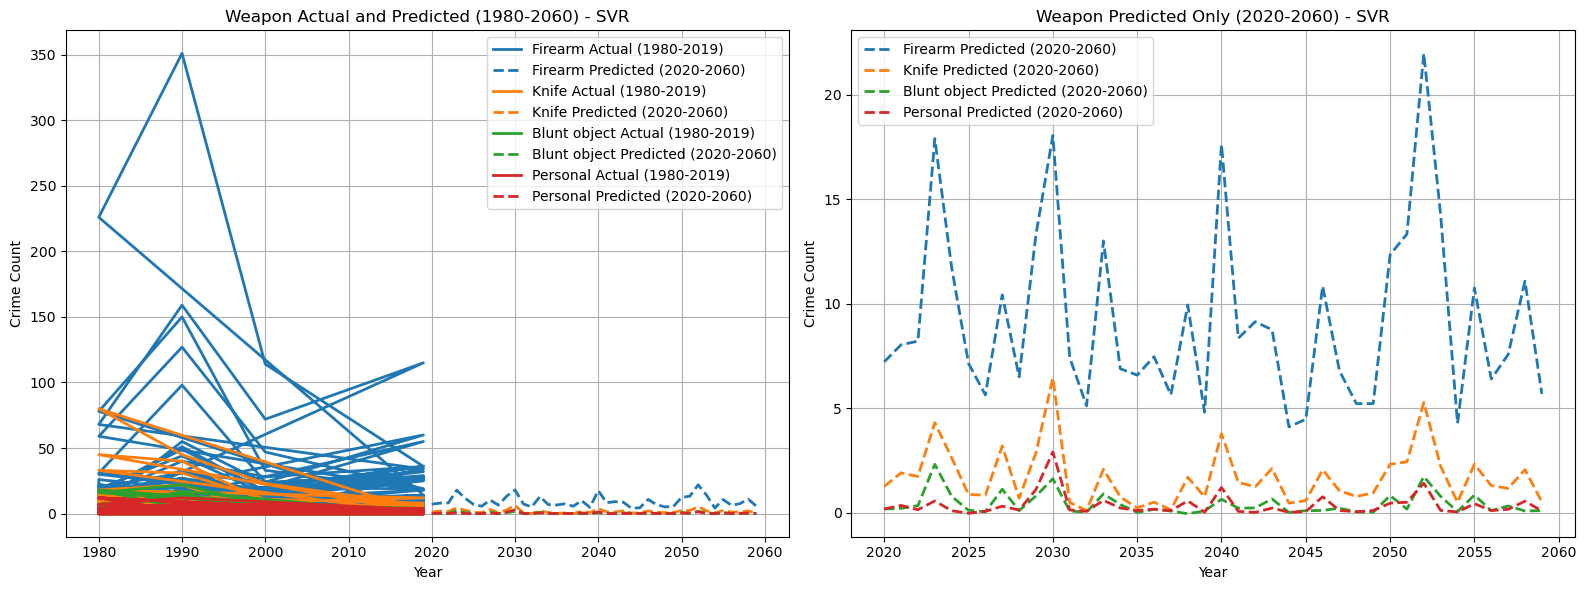


-------------------- Category: Offenders --------------------
Targets: ['One offender involved', 'Two or more offenders involved']
------------------------------------------------------------


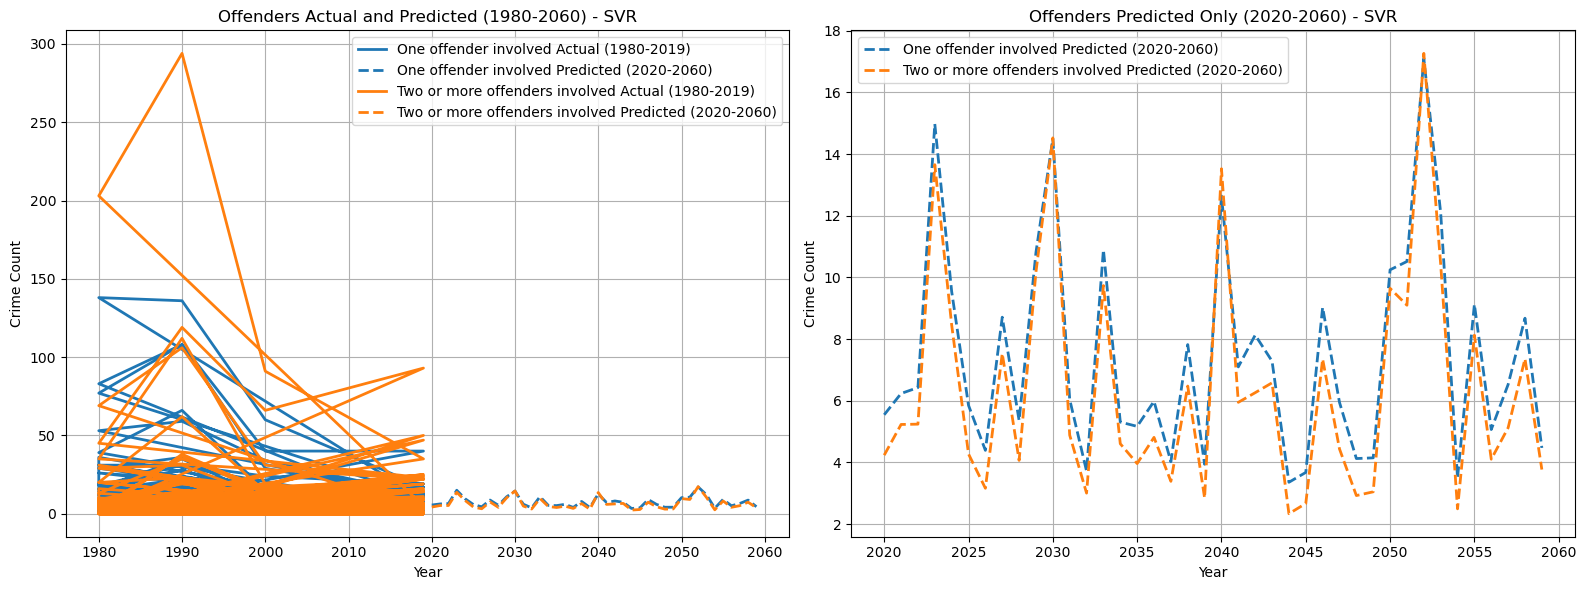


-------------------- Category: Education --------------------
Targets: ['Percent of adults with less than a high school diploma', 'Percent of adults with a high school diploma only']
------------------------------------------------------------


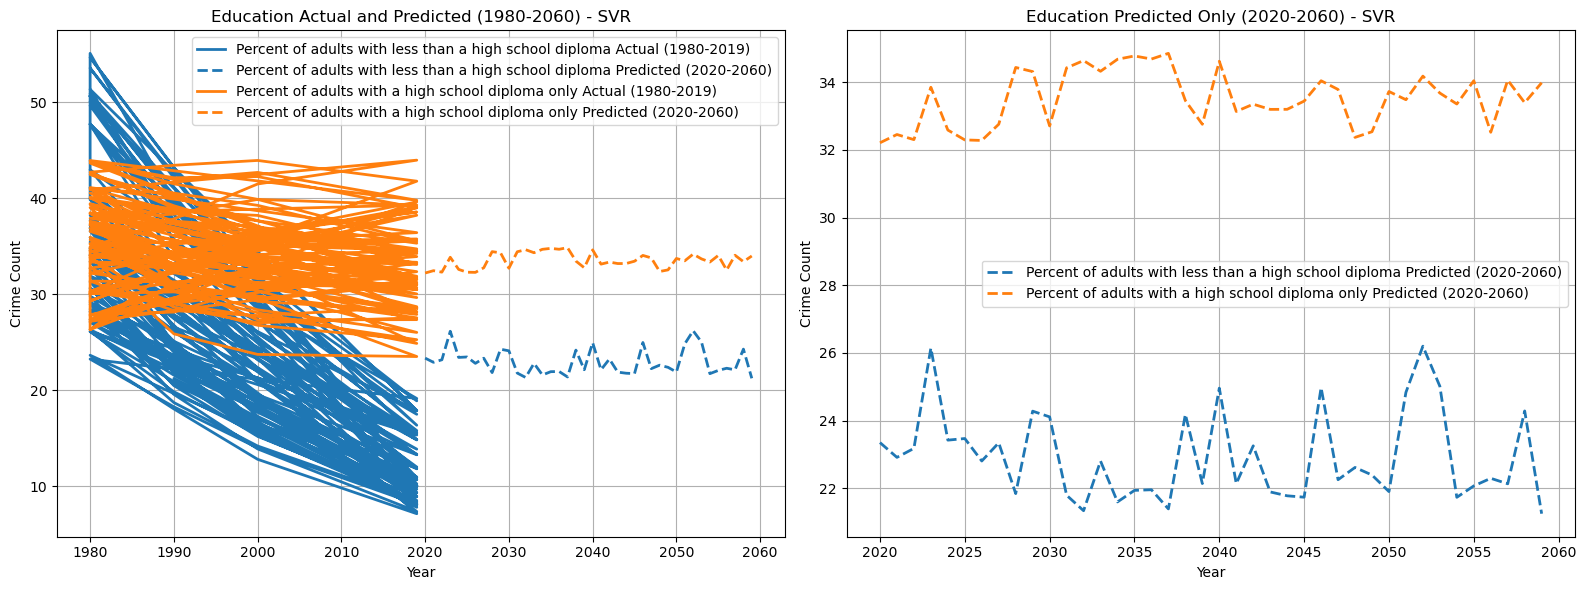

                                               Target   Category Model    MAE  \
0                                                Male     Gender   SVR  10.37   
1                                              Female     Gender   SVR   1.08   
2                                               White       Race   SVR   3.36   
3                                               Black       Race   SVR   7.84   
4                         Amer. Indian/Alaskan Native       Race   SVR   0.15   
5                         Asian/Nat. Hawaiian/Pac Isl       Race   SVR   0.16   
6                                              Family   Relation   SVR   1.28   
7                                        Acquaintance   Relation   SVR   4.88   
8                                            Stranger   Relation   SVR   3.96   
9                                             Firearm     Weapon   SVR   6.99   
10                                              Knife     Weapon   SVR   1.82   
11                          

In [7]:
valid_features = [col for col in features if col in merged_data.columns]
valid_features.append('Year')

# prep the future_X data
last_data = merged_data[merged_data["Year"] == 2019].drop(columns=["Year"] + all_target_columns)
future_years = pd.DataFrame({"Year": np.arange(2020, 2060)})
future_X = pd.concat([future_years, pd.DataFrame(np.tile(last_data.values, (len(future_years), 1)), columns=last_data.columns)], axis=1)
# using this to predict
future_X = future_X[valid_features]

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(),
    "Gradient Boosting": GradientBoostingRegressor(),
    "SVR": SVR()
}

for model_name, model in models.items():

    print("="*80)
    print(f"MODEL: {model_name}")
    print("="*80)

    evaluation_results = []


    # for each target, train and predict
    for y, targets, category in zip(y_all, all_targets, all_target_names):

        print("\n" + "-"*20 + f" Category: {category} " + "-"*20)
        print(f"Targets: {targets}")
        print("-"*60)

        # split data (80% training, 20% testing)
        train_size = int(len(merged_data) * 0.8)
        X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
        y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

        # normalize features
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # train on random forest
        target_models = {}
        for target in targets:
            model_instance = clone(model)
            model_instance.fit(X_train_scaled, y_train[target])
            target_models[target] = model_instance

        # evaluate model
        for target, model_instance in target_models.items():
            y_pred = model_instance.predict(X_test_scaled)
            mae = mean_absolute_error(y_test[target], y_pred)
            mse = mean_squared_error(y_test[target], y_pred)
            r2 = r2_score(y_test[target], y_pred)

            evaluation_results.append({
                "Target": target,
                "Category": category,
                "Model": model_name,
                "MAE": round(mae, 2),
                "MSE": round(mse, 2),
                "R2 Score": round(r2, 2)
            })


        # now predict future values (2020-2060)
        future_X_scaled = scaler.transform(future_X[features])
        future_predictions = {target: model_instance.predict(future_X_scaled) for target, model_instance in target_models.items()}

        
        # PLOT
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))  # 1 row, 2 columns, adjust figsize as needed

        # --- Left plot: Actual and Predicted ---
        for target in targets:
            color = plt.cm.tab10(targets.index(target) % 10)
            actual_data = merged_data[target]
            if actual_data.ndim > 1:
                actual_data = actual_data.mean(axis=1)
            axes[0].plot(merged_data["Year"], actual_data, label=f"{target} Actual (1980-2019)", color=color, linewidth=2)

            target_predictions = future_predictions[target]
            if target_predictions.ndim > 1:
                target_predictions = target_predictions.mean(axis=1)
            if target_predictions.shape[0] != 40:
                target_predictions = target_predictions[:40]
            axes[0].plot(np.arange(2020, 2060), target_predictions, linestyle="dashed", label=f"{target} Predicted (2020-2060)", color=color, linewidth=2)

        axes[0].set_xlabel("Year")
        axes[0].set_ylabel("Crime Count")
        axes[0].set_title(f"{category} Actual and Predicted (1980-2060) - {model_name}")
        axes[0].legend()
        axes[0].grid(True)

        # --- Right plot: Future Predictions Only ---
        for target in targets:
            target_predictions = future_predictions[target]
            if target_predictions.ndim > 1:
                target_predictions = target_predictions.mean(axis=1)
            if target_predictions.shape[0] != 40:
                target_predictions = target_predictions[:40]
            axes[1].plot(np.arange(2020, 2060), target_predictions, linestyle="dashed", label=f"{target} Predicted (2020-2060)", linewidth=2)

        axes[1].set_xlabel("Year")
        axes[1].set_ylabel("Crime Count")
        axes[1].set_title(f"{category} Predicted Only (2020-2060) - {model_name}")
        axes[1].legend()
        axes[1].grid(True)

        plt.tight_layout()
        plt.show()
    
    # print evaulation table of model
    eval_df = pd.DataFrame(evaluation_results)
    print(eval_df)









Overall Random Forest and Gradient boosting models performed the best with consistently lower MAE and MSE values, and higher R2 scores across multiple categories. The SVR model performed the worse overall. But with addition of education factor there was no significant changes in the models performance. It slightly increased the prediction power in some category and reduced in other categries.